# Laboratorio 5: Clasificación 🤗

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos - Primavera 2024</strong></center>


### Cuerpo Docente:

- Profesores: Stefano Schiappacasse, Sebastián Tinoco
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Angelo Muñoz, Valentina Zúñiga

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Hayter Cortés Muñoz
- Nombre de alumno 2:

### **Link de repositorio de GitHub:** [Repositorio](https://github.com/HayterCortes/HayterCortes)

### Temas a tratar
- Clasificación en problemas desbalanceados
- Lightgbm y xgboost
- Pipelines

## Reglas:

- **Grupos de 2 personas**
- Fecha de entrega: 6 días de plazo con descuento de 1 punto por día. Entregas Martes a las 23:59.
- Instrucciones del lab el viernes a las 16:15 en formato online. Asistencia no es obligatoria, pero se recomienda fuertemente asistir.
- <u>Prohibidas las copias</u>. Cualquier intento de copia será debidamente penalizado con el reglamento de la escuela.
- Tienen que subir el laboratorio a u-cursos y a su repositorio de github. Labs que no estén en u-cursos no serán revisados. Recuerden que el repositorio también tiene nota.
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Pueden usar cualquier material del curso que estimen conveniente.




### Objetivos principales del laboratorio
- Comprender cómo trabajar con problemas de clasificación con clases desbalanceadas.
- Aplicar los modelos lightgbm y xgboost.
- Practicar Pipelines

# Parte Teórica [12 puntos]




1. Explique cuál es la diferencia entre los datos de entrenamiento y validación. [1 punto]

2. Explique cuál es el principal desafío al trabajar problemas de clasificación con data no supervisada. [1 punto]

3. Explique en **sus palabras** qué es la matriz de confusión y para qué se utiliza. [1 puntos]

4. Escriba la fórmula de las siguientes métricas y explique con **sus palabras** cómo se interpretan. [1 punto cada uno]

  * Accuracy
  * Precision
  * Recall
  * F1 score

5. Explique qué métrica recomendaría para los siguientes contextos de clasificación. [1 punto cada uno]

  * Mantenimiento predictivo de fallas de maquinaria pesada en la industria minera.  
  * Detección de enfermedades altamente contagiosas.
  * Aprobación de créditos de alto riesgo.
  * Detección de crímenes.

6. Explique qué es la calibración de modelos y para qué se usa. [1 punto]


**Respuesta:**

1. Los datos de entrenamiento son el subconjunto rotulado del que el algoritmo aprende: el modelo ajusta sus parámetros minimizando una función de pérdida sobre estas instancias; los datos de validación, en cambio, no participan en ese ajuste sino que sirven para estimar el desempeño “fuera de muestra” durante el desarrollo, guiando decisiones de hiperparámetros y detectando sobre-ajuste antes de evaluar en el test final.

2. El principal desafío al atacar problemas de clasificación cuando no se dispone de data no supervisada, es que no existe una referencia objetiva con la cual evaluar, seleccionar o interpretar los grupos descubiertos: hay que definir criterios internos o semi-supervisados para valorar la calidad de los clusters, y luego traducirlos a clases significativas para el dominio, lo que puede inducir ambigüedad y sesgo.

3. Una matriz de confusión es una tabla que cruza las predicciones del modelo con las etiquetas reales y contabiliza Verdaderos Positivos, Verdaderos Negativos, Falsos Positivos y Falsos Negativos; se usa porque condensa, en un solo objeto, la información necesaria para derivar casi todas las métricas de clasificación y para visualizar de forma rápida en qué tipo de errores incurre el modelo.

4. * $Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$: Mide la proporción total de aciertos sobre todos los casos y se interpreta como la probabilidad de clasificar correctamente a un ejemplo tomado al azar, pero puede ser engañosa en datasets desbalanceados.


    * $Precision = \frac{TP}{TP + FP}$: Entre las instancias que el modelo marcó como positivas, indíca qué fracción realmente lo eran; por lo tanto, resume la fiabilidad de las alertas y es clave cuando los falsos positivos son costosos.


   * $Recall = \frac{TP}{TP + FN}$: Refleja la capacidad de capturar todos los positivos reales, es decir, el porcentaje de casos positivos que no se le escapan al modelo, y se prioriza cuando los falsos negativos son críticos.


   * $F_1 = 2 \,\frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$: Es la media armónica de precisión y recall, penaliza desequilibrios entre ambas y ofrece un único valor cuando interesa equilibrar los dos tipos de error.


5. Métricas que recomendaría para los siguientes contextos de clasificación. 

  * Mantenimiento predictivo de fallas de maquinaria pesada en la industria minera: Recomendaría Recall porque la prioridad es no dejar pasar fallas reales que podrían causar paradas costosas o accidentes; los falsos positivos implican revisiones adicionales, menos onerosas que una falla no detectada.
  * Detección de enfermedades altamente contagiosas: El Recall es vital, pues se acepta un mayor número de falsos positivos antes que perder casos reales.  
  * Aprobación de créditos de alto riesgo: Aquí pesa más la Precision sobre la clase “aprobado”, ya que conceder un crédito a un solicitante riesgoso (falso positivo) supone pérdidas financieras mayores que rechazar por error a un buen cliente.
  * Detección de crímenes: Un equilibrio entre no omitir delitos y emitir alertas falsas sería adecuado, por lo que podría usarse el F1 score para balancear Precision y Recall.

6. La calibración de modelos es el proceso de ajustar o evaluar la correspondencia entre las probabilidades de predicción de un clasificador y las frecuencias reales observadas. Un modelo bien calibrado permite que los casos a los que asigna, por ejemplo, 0.8 de probabilidad de pertenecer a la clase positiva realmente sean positivos en ~80 % de las ocasiones, lo que resulta esencial cuando las salidas probabilísticas se usan para tomar decisiones basadas en riesgo o para combinar modelos.


# Parte práctica [48 puntos]

**Los Datos**

Para este laboratorio deberán trabajar con el csv `statsplayers.csv`, donde deberán aplicar algoritmos de aprendizaje supervisado de clasificación en base a características que describen de jugadores de fútbol.

Para comenzar cargue el dataset señalado y a continuación vea el reporte **`Player_Stats_Report.html`** (adjunto en la carpeta del enunciado) que describe las características principales del `DataFrame`.

In [18]:
import pandas as pd

# Cargar el dataset 
df = pd.read_csv("stats_players.csv") 

# Inspección 
print(f"Dimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas")
display(df.head())    
df.info()            


Dimensiones del dataset: 17588 filas × 39 columnas


,Name,Nationality,National_Position,Club_Position,Height,Weight,Preffered_Foot,Age,Work_Rate,Weak_foot,...,Agility,Jumping,Heading,Shot_Power,Finishing,Long_Shots,Curve,Freekick_Accuracy,Penalties,Volleys
0,Cristiano Ronaldo,Portugal,LS,LW,185,80,Right,32,High / Low,4,...,90,95,85,92,93,90,81,76,85,88
1,Lionel Messi,Argentina,RW,RW,170,72,Left,29,Medium / Medium,4,...,90,68,71,85,95,88,89,90,74,85
2,Neymar,Brazil,LW,LW,174,68,Right,25,High / Medium,5,...,96,61,62,78,89,77,79,84,81,83
3,Luis Suárez,Uruguay,LS,ST,182,85,Right,30,High / Medium,4,...,86,69,77,87,94,86,86,84,85,88
4,Manuel Neuer,Germany,GK,GK,193,92,Right,31,Medium / Medium,4,...,52,78,25,25,13,16,14,11,47,11


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17588 entries, 0 to 17587
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Name               17588 non-null  object
 1   Nationality        17588 non-null  object
 2   National_Position  1075 non-null   object
 3   Club_Position      17587 non-null  object
 4   Height             17588 non-null  int64 
 5   Weight             17588 non-null  int64 
 6   Preffered_Foot     17588 non-null  object
 7   Age                17588 non-null  int64 
 8   Work_Rate          17588 non-null  object
 9   Weak_foot          17588 non-null  int64 
 10  Skill_Moves        17588 non-null  int64 
 11  Ball_Control       17588 non-null  int64 
 12  Dribbling          17588 non-null  int64 
 13  Marking            17588 non-null  int64 
 14  Sliding_Tackle     17588 non-null  int64 
 15  Standing_Tackle    17588 non-null  int64 
 16  Aggression         17588 non-null  int64

## 1. Predicción de Seleccionados Nacionales [14 puntos]

<p align="center">
  <img src="https://www.futuro.cl/wp-content/uploads/2016/06/chile-argentina-meme-12.jpg" width="300">
</p>



### 1.1 Preprocesamiento [5 puntos]

Tareas:

1. Genere los labels para la clasificación binaria en una variable llamada `label`. Para esto, trabaje sobre el atributo `National_Position` suponiendo que los valores nulos son jugadores no seleccionados para representar a su país. [Sin puntaje]

2. Hecho esto, ¿cuántos ejemplos se tienen por cada clase? Comente lo que observa. [1 punto]

3. Genere un `ColumnTransformer` en donde especifique las transformaciones que hay que realizar para cada columna (por ejemplo StandarScaler, MinMaxScaler, OneHotEncoder, etc...) para que puedan ser utilizadas correctamente por el modelo predictivo y guárdelo en una variable llamada `col_transformer`. [2 puntos]

4. Comente y justifique las transformaciones elegidas sobre cada una de las variables (para esto utilice el material `Player_Stats_Report.html` que viene en el zip del lab), al igual que las transformaciones aplicadas. [2 puntos]

**Respuesta:**

#### Labels para la clasificación binaria:

In [19]:
# Etiqueta binaria
df["label"] = df["National_Position"].notna().astype(int)

# Revisión
print(df["label"].value_counts(dropna=False))
print("\nProporción de seleccionados nacionales:",
      df["label"].mean().round(3))

# Eliminación de la variable que generó el label
df = df.drop(columns=["National_Position"])

label
0    16513
1     1075
Name: count, dtype: int64

Proporción de seleccionados nacionales: 0.061


#### Ejemplos por cada clase:
Hay **16513 jugadores etiquetados como 0** (no seleccionados) y **1075 jugadores etiquetados como 1** (seleccionados nacionales), lo que equivale a ≈ 94 % de la clase negativa frente a apenas ≈ 6 % de la positiva. Esta desproporción indica un problema de **clases desbalanceadas**. Un modelo que solo priorice la precisión global tenderá a predecir siempre la clase mayoritaria y aun así logrará un alto accuracy, pero fallará en identificar a los verdaderos seleccionados. Por ello puede ser necesario usar métricas sensibles al desbalance.

#### ColumnTransformer:

In [20]:
# ColumnTransformer 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np

# Eliminación de identificadores y de la columna ya usada para crear el label
df = df.drop(columns=["Name", "National_Position"], errors="ignore")

# a) Preffered_Foot: Binario (Right = 1, Left = 0)
df["Preffered_Foot"] = (df["Preffered_Foot"] == "Right").astype(np.int8)

# b) Work_Rate: Dos columnas ordinales (ataque y defensa)
rate_map = {"Low": 0, "Medium": 1, "High": 2}
wr_split = df["Work_Rate"].str.split(" / ", expand=True)
df["WR_attack"]  = wr_split[0].replace(rate_map).astype(np.int8)
df["WR_defense"] = wr_split[1].replace(rate_map).astype(np.int8)
df = df.drop(columns=["Work_Rate"])

# Listas de columnas por tipo
num_cols = (
    df.select_dtypes(include=["int8", "int16", "int32", "int64",
                              "float16", "float32", "float64"])
      .columns
      .difference(["label"])                
)

cat_cols = ["Nationality", "Club_Position"]  # únicas categóricas nominales

# Construcción del ColumnTransformer
col_transformer = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),                    # escala numéricas
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)  # one-hot
    ],
    remainder="drop",
    n_jobs=-1
)

print(f"ColumnTransformer creado: {len(num_cols)} numéricas + "
      f"{len(cat_cols)} categóricas")


ColumnTransformer creado: 36 numéricas + 2 categóricas


#### Comentarios y justificaciones de las transformaciones elegidas sobre cada una de las variables:
Tras revisar `Player_Stats_Report.html` noté que **`Name`** presenta una cardinalidad extrema (17133 valores únicos, 97 % únicos), por lo que se descarta para evitar 17000 dummies sin valor predictivo. **`National_Position`** posee 93,9 % de vacíos y solo sirvió para construir la etiqueta, así que también se elimina para prevenir *data-leakage*.  Las ocho variables numéricas básicas (Edad, Altura, Peso, Weak foot, Skill Moves, más los 30 atributos FIFA) carecen de nulos y comparten rangos acotados (20-99 en ratings, 155-207 cm en altura y 48-110 kg en peso), por lo que basta un **`StandardScaler`** para homogeneizar la escala sin distorsionar la forma de sus distribuciones.  **`Preffered_Foot`** es binaria (13494 diestros, 4094 zurdos) y se convierte a un indicador 0/1, evitando dos columnas dispersas.  **`Work_Rate`** combina nueve etiquetas cuya semántica “Low < Medium < High” aconseja dividirla en **`WR_attack`** y **`WR_defense`**, mapeadas ordinalmente 0-2; esta descomposición conserva su orden y reduce sparsidad frente a un *one-hot* mientras sigue capturando la diferencia entre trabajo ofensivo y defensivo (la modalidad dominante, “Medium/Medium”, cubre 56 % del dataset).  De las categóricas restantes, **`Nationality`** (160 países) y **`Club_Position`** (29 etiquetas, altamente desbalanceadas con “Sub” y “Res” a la cabeza) no poseen un orden natural, por lo que se codifican con **`OneHotEncoder`** usando `handle_unknown="ignore"` para manejar países o posiciones inéditas en test; aunque `Nationality` tiene alta cardinalidad, 160 columnas son aceptables frente a 17588 filas y la variable puede ser informativa de nivel competitivo. Finalmente, a pesar de las correlaciones fuertes marcadas entre Altura, Peso y varios atributos físicos, no se descartan columnas porque los modelos basados en árboles/ensambles toleran colinealidad. Así, cada variable recibe la transformación mínima necesaria para ser numérica y escalada o para representar su naturaleza categórica sin inflar dimensionalidad, manteniendo coherencia con la evidencia descriptiva del informe.

### 1.2 Entrenamiento [3 puntos]

Ahora, vamos a entrenar los pipelines generados en los pasos anteriores. Para esto, debe realizar las siguientes tareas:

1. Separe los datos de entrenamiento en un conjunto de entrenamiento y de prueba  (la proporción queda a su juicio). En este paso, seleccione los ejemplos de forma aleatoria e intente mantener la distribución original de labels de cada clase en los conjuntos de prueba/entrenamiento. (vea la documentación de `train_test_split`). [1 puntos]


2. Defina un pipeline llamado `pipeline_xgboost` y otro llamado `pipeline_lightgbm`. Estos pipelines deben tener el mismo ColumnTransformer definido en la sección de preprocesamiento, pero deben variar los clasificadores de acuerdo al nombre de cada pipeline. [1 puntos]

3. Entrene los pipelines. [1 punto]



**Respuesta:**

#### Separación de datos
$stratify=y$ garantiza que tanto el 80 % de entrenamiento como el 20 % de prueba conserven la proporción de seleccionados nacionales (~6 %), evitando sesgos de clase al evaluar el modelo.

In [21]:
from sklearn.model_selection import train_test_split

# X = características 
X = df.drop(columns=["label"])
y = df["label"]

# 80 % entrenamiento, 20 % prueba; estratificación preserva la proporción 0/1
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,         
    stratify=y,              # mantiene la distribución original de clases
    random_state=42          
)

print(f"Train size: {X_train.shape[0]}  –  Test size: {X_test.shape[0]}")
print("Proporción de positivos en train:", y_train.mean().round(3))
print("Proporción de positivos en test: ", y_test.mean().round(3))


Train size: 14070  –  Test size: 3518
Proporción de positivos en train: 0.061
Proporción de positivos en test:  0.061


#### Pipelines

In [ ]:
# Pipelines con el mismo preprocesamiento y distintos clasificadores
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Peso de clase para el desbalance (negativos / positivos)
ratio = (y_train.value_counts()[0] / y_train.value_counts()[1])

# Pipeline con XGBoost
pipeline_xgboost = Pipeline([
    ("prep", col_transformer),
    ("clf", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=ratio,  
        random_state=42
    ))
])

# Pipeline con LightGBM
pipeline_lightgbm = Pipeline([
    ("prep", col_transformer),
    ("clf", LGBMClassifier(
        objective="binary",
        n_estimators=500,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight={0: 1, 1: ratio},  
        random_state=42
    ))
])

#### Entrenamiento de los pipelines

In [23]:
# Entrenamiento XGBoost
pipeline_xgboost.fit(X_train, y_train)

# Entrenamiento LightGBM
pipeline_lightgbm.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 860, number of negative: 13210
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001490 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2665
[LightGBM] [Info] Number of data points in the train set: 14070, number of used features: 134
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


Pipeline(memory=None,
         steps=[('prep',
                 ColumnTransformer(n_jobs=-1, remainder='drop',
                                   sparse_threshold=0.3,
                                   transformer_weights=None,
                                   transformers=[('num',
                                                  StandardScaler(copy=True,
                                                                 with_mean=True,
                                                                 with_std=True),
                                                  Index(['Acceleration', 'Age', 'Aggression', 'Agility', 'Balance',
       'Ball_Control', 'Composure', 'Crossing', 'Curve', 'Dribbling',
       'Finishing', 'Freekick_Accura...
                                class_weight={0: 1, 1: 15.36046511627907},
                                colsample_bytree=0.8, importance_type='split',
                                learning_rate=0.05, max_depth=-1,
                                min_child_samples=20, min_child_weight=0.001,
                                min_split_gain=0.0, n_estimators=500,
                                n_jobs=None, num_leaves=31, objective='binary',
                                random_state=42, reg_alpha=0.0, reg_lambda=0.0,
                                subsample=0.8, subsample_for_bin=200000,
                                subsample_freq=0))],
         verbose=False)

### 1.3 Resultados [6 puntos]

1. Calcule las métricas accuracy, precisión y recall de la clase positiva (la que indica que un jugador es seleccionado nacional) para evaluar el rendimiento de los distintos modelos. Verifique sus resultados usando `classification_report`. [2 puntos]

2. Explique qué implican los valores de accuracy, precisión y recall de la clase positiva (la que indica que un jugador es seleccionado nacional) y cómo influye la cantidad de ejemplos por clase en los resultados obtenidos. [2 puntos]

3. Explique qué métrica le parece más adecuada y concluya qué modelo tiene un mejor desempeño. [2 puntos]

**Respuesta:**

#### Métricas de la clase positiva


In [24]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report
)

def evaluate(model, name):
    y_pred  = model.predict(X_test)
    # Accuracy global
    acc  = accuracy_score(y_test, y_pred)
    # Métricas de la clase positiva (label=1)
    prec = precision_score(y_test, y_pred, pos_label=1)
    rec  = recall_score(y_test, y_pred,   pos_label=1)

    print(f"\n=== {name} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}\n")
    # Verificación detallada
    print(classification_report(y_test, y_pred, digits=3))

# Evaluación de ambos pipelines
evaluate(pipeline_xgboost,  "XGBoost")
evaluate(pipeline_lightgbm, "LightGBM")



=== XGBoost ===
Accuracy : 0.9386
Precision: 0.4985
Recall   : 0.7674

              precision    recall  f1-score   support

           0      0.984     0.950     0.967      3303
           1      0.498     0.767     0.604       215

    accuracy                          0.939      3518
   macro avg      0.741     0.859     0.786      3518
weighted avg      0.955     0.939     0.945      3518


=== LightGBM ===
Accuracy : 0.9460
Precision: 0.5486
Recall   : 0.6558

              precision    recall  f1-score   support

           0      0.977     0.965     0.971      3303
           1      0.549     0.656     0.597       215

    accuracy                          0.946      3518
   macro avg      0.763     0.810     0.784      3518
weighted avg      0.951     0.946     0.948      3518



#### Implicancias de los resultados de las métricas
En este problema la **accuracy ≈ 0,94** indica que ambos modelos aciertan en torno al 94 % de los 3 518 casos de prueba; sin embargo, como sólo el 6 % corresponde a la clase positiva (“seleccionado nacional”), esa cifra refleja sobre todo lo fácil que es clasificar bien a los **no** convocados: basta con etiquetar casi todo como 0 para inflar la exactitud. Por eso examinamos la **precisión** y el **recall** de la clase positiva. La **precisión (≈ 0,50 en XGBoost, 0,55 en LightGBM)** expresa que sólo la mitad de los jugadores que el modelo marca como seleccionados lo son realmente; un valor moderado-bajo porque hay muchos falsos positivos, acentuado por la gran mayoría negativa. El **recall (≈ 0,77 en XGBoost, 0,66 en LightGBM)** señala la proporción de seleccionados reales que el modelo recupera: XGBoost captura más convocados pero comete más “falsas alarmas”, mientras que LightGBM es más cauto y deja escapar parte de ellos para ganar fiabilidad. La marcada desigualdad de ejemplos (≈ 1 : 15) hace que la métrica global esté dominada por la clase 0 y obliga a ponderar o estratificar; sin estos ajustes, un clasificador trivial que siempre predijera “no seleccionado” obtendría ~0,94 de accuracy pero 0 de recall positivo. Así, las métricas específicas de la clase minoritaria revelan el verdadero desempeño en el objetivo crítico y evidencian la necesidad de balancear el costo entre falsos positivos y falsos negativos.

### Métrica más adecuada y mejor modelo
Debido al fuerte desbalance, en **accuracy** hay sesgo por la clase mayoritaria. **Precision** y **recall** capturan aspectos opuestos, por lo que la métrica más adecuada es  **F1-score de la clase positiva**, que armoniza ambas y penaliza los desequilibrios típicos de este contexto. Comparando los modelos, XGBoost entrega un F1 = 0,604 mientras LightGBM alcanza 0,597. La diferencia es pequeña pero, junto con el mayor recall (0,77 vs 0,66), indica que **XGBoost** ofrece el mejor desempeño global para identificar jugadores convocados sin deteriorar excesivamente la precisión.

## 2. Predicción de posiciones de jugadores [4 puntos]

<p align="center">
  <img src="https://pbs.twimg.com/media/E1rfA1aWEAYU6Ny.jpg" width="300">
</p>

En una nueva jornada de desmesuradas transacciones deportivas, Renacín escuchó a sus colegas discutir acerca de que el precio de cada jugador depende en gran medida de la posición en la cancha en la que juega. Y además, que hay bastantes jugadores nuevos que no tienen muy claro en que posición verdaderamente brillarían, por lo que actualmente puede que actualmente estén jugando en posiciones sub-optimas.

Viendo que los resultados del primer análisis no son tan esperanzadores, el corporeo los comanda a cambiar su tarea: ahora, les solicita que construyan un clasificador enfocado en predecir la mejor posición de los jugadores en la cancha según sus características.

Para lograr esto, primero, les pide que etiqueten de la siguiente manera los valores que aparecen en el atributo `Club_Position`, pidiendo que agrupen los valores en los siguientes grupos:

**Nota**:  Renacín les recalca que **no deben utilizar los valores ```Sub``` y ```Res``` de esta columna**.

```python
ataque = ['ST', 'CF']
central_ataque = ['RW', 'CAM', 'LW']
central = ['RM', 'CM', 'LM']
central_defensa = ['RWB', 'CDM', 'LWB']
defensa = ['RB', 'CB', 'LB']
arquero = ['GK']
```

La elección del clasificador se justificar en base a la siguiente [guía](https://scikit-learn.org/stable/tutorial/machine_learning_map/index.html) y se deben comentar los resultados obtenidos en la clasificación.

**Tareas:** [1 punto por tarea]

1. En un nuevo dataframe, aplique las etiquetas descritas anteriormente en cada uno de los valores señalados en esta sección y guárdelos en la variable `label`.
2. Cuente cuántos por clase quedan.
3. Entrene el nuevo pipeline y ejecute una evaluación de este.  
4. Comente los resultados obtenidos.

**Respuesta:**

In [25]:
# Filtrado de suplentes / reservas y mapeo de cada posición a su línea
mask = ~df["Club_Position"].isin(["Sub", "Res"])
df_pos = df.loc[mask].copy()

map_pos = {
    **dict.fromkeys(['ST', 'CF', 'SS', 'RS', 'LS'], 'ataque'),
    **dict.fromkeys(['RW', 'LW', 'RF', 'LF'], 'central_ataque'),
    **dict.fromkeys(['CAM', 'RM', 'CM', 'LM'], 'central'),
    **dict.fromkeys(['RWB', 'LWB', 'CDM'], 'central_defensa'),
    **dict.fromkeys(['RB', 'CB', 'LB'], 'defensa'),
    'GK': 'arquero'
}
df_pos["label"] = df_pos["Club_Position"].map(map_pos)

# Eliminación de cualquier registro cuya posición no entró en el diccionario
df_pos = df_pos.dropna(subset=["label"])

# Distribución de clases
print("Ejemplos por clase:")
print(df_pos["label"].value_counts(), "\n")

# ColumnTransformer 
num_cols = (
    df_pos.select_dtypes(include=["int8", "int16", "int32", "int64",
                                  "float16", "float32", "float64"])
          .columns
          .difference(["label"])
)

cat_cols = ["Nationality"]                           # única nominal restante

col_transformer_pos = ColumnTransformer(
    [("num", StandardScaler(), num_cols),
     ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)],
    remainder="drop",
    n_jobs=-1
)

# Train-test split estratificado
X = df_pos.drop(columns=["label", "Club_Position"])
y = df_pos["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Pipeline + Gradient Boosting 
from sklearn.ensemble import GradientBoostingClassifier

pipeline_gb = Pipeline([
    ("prep", col_transformer_pos),
    ("clf", GradientBoostingClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

pipeline_gb.fit(X_train, y_train)

# Evaluación
from sklearn.metrics import classification_report, accuracy_score

y_pred = pipeline_gb.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy global: {acc:.4f}\n")
print(classification_report(y_test, y_pred, digits=3))


Ejemplos por clase:
label
central            1222
defensa            1180
ataque              841
arquero             632
central_ataque      290
central_defensa     209
Name: count, dtype: int64 


Accuracy global: 0.7920

                 precision    recall  f1-score   support

        arquero      1.000     1.000     1.000       126
         ataque      0.852     0.857     0.855       168
        central      0.674     0.776     0.721       245
 central_ataque      0.350     0.121     0.179        58
central_defensa      0.500     0.214     0.300        42
        defensa      0.835     0.919     0.875       236

       accuracy                          0.792       875
      macro avg      0.702     0.648     0.655       875
   weighted avg      0.769     0.792     0.772       875



El clasificador alcanza un **79 % de accuracy**, pero la matriz de métricas revela un rendimiento muy desigual entre líneas: distingue sin fallos a los **arqueros** (F1 = 1,00) y con alta precisión/recall a **defensas** (0,88) y **atacantes** (0,86), clases cuyos atributos físicos y técnicos son marcadamente diferentes. Sin embargo, el desempeño cae para los roles de mediocampo, donde **centrales** obtienen solo F1 = 0,72 y, de forma crítica, los grupos **central_ataque** y **central_defensa** registran F1 de 0,18 y 0,31 porque el modelo recupera menos del 25 % de sus verdaderos casos. Esta brecha se explica por el **desbalance de clase y la superposición estadística**: los atributos de los mediocentros ofensivos/defensivos se solapan tanto con los de atacantes como con los de defensas, por lo que el ensamble de árboles, entrenado con pocos ejemplos positivos, aprende reglas demasiado específicas o directamente ignora esas hojas. En síntesis, el modelo sólo es fiable para detectar posiciones extremas (GK, líneas defensiva y de ataque). 

## 3. Predicciones de Seleccionados Nacionales para el Jere Klein [30 puntos]

<center>
<img src='https://www.radioactiva.cl/wp-content/uploads/2024/04/Jere-Klein-1-768x432.webp' width=500 />

Después de alcanzar la fama como cantante urbano, Jere Klein decide explorar una nueva faceta. Con su amor por el fútbol y convencido de que los artistas urbanos poseen un talento y versatilidad excepcionales, Jere se embarca en un proyecto innovador: desarrollar un sistema de inteligencia artificial capaz de identificar a jugadores que tienen potencial para convertirse en futbolistas profesionales. Su teoría es que muchos artistas del género urbano chileno, con sus habilidades únicas y su disciplina, podrían destacarse también en el deporte. Con este sistema, Jere espera no solo abrir nuevas oportunidades para sus colegas artistas, sino también demostrar la amplia gama de talentos que pueden ofrecer.

### 2.1 ¿Qué modelo de árbol es más de "pana"? [10 puntos]

<center>
<img src='https://64.media.tumblr.com/39189215a7d3d96823cb359f35b44e05/tumblr_psmrhrR3Xw1qf5hjqo4_540.gif' width=300 />


**Tareas**


1. Considerando la variable llamada `label` creada en la sección 1.1. Para determinar cuál modelo de árbol sería más adecuado para la tarea en cuestión, utilice PyCaret. Este deberá centrarse exclusivamente en modelos de tipo árbol. Jere ha especificado que busca un modelo que tome decisiones rápidamente y que tenga una baja tasa de falsos positivos, ya que planea invertir en estos jugadores. [3 puntos]

Para la comparación, utilice los siguientes modelos:

```python
['et', 'rf', 'dt', 'xgboost', 'lightgbm', 'catboost']
```

2. Explique brevemente qué son los modelos de la siguiente lista `['et', 'rf', 'dt']` y como funcionan. [3 puntos]

3. Tras realizar la comparación de modelos, seleccione aquel que muestre el mejor rendimiento en términos de velocidad y precisión, especialmente en la reducción de falsos positivos. Utilice la función `evaluate_model` de PyCaret para revisar y analizar los resultados obtenidos en los siguientes aspectos:

  - **Confusión Matrix**: ¿Cómo se encuentran la tasa de verdaderos positivos y verdaderos negativos?
  - **Threshold**: ¿Es acaso el umbral por defecto del modelo el mejor para las predicciones?
  - **Feature Importance**: ¿Cuáles son las variables con mejor desempeño? ¿A qué podría deberse esto?
  - **Learning Curve**: ¿El modelo presenta algún problema?

  [4 puntos]

**Respuesta**

#### Comparación de modelos usando PyCaret:

In [26]:
from pycaret.datasets import get_data
from pycaret.classification import *
import os

os.environ["PYCARET_CUSTOM_LOGGING_LEVEL"] = "CRITICAL"

# DataFrame sin fugas 
df_pc = df.drop(columns=["National_Position", "Name"], errors="ignore")

# Configuración: 80 % train / 20 % test, SMOTE para balancear
exp = setup(
    data=df_pc,
    target="label",
    session_id=42,
    train_size=0.8,
    fix_imbalance=True,          # SMOTE en la clase minoritaria (~6 %)
    verbose=False,               
    fold=5,
    fold_strategy="stratifiedkfold"
)

# Comparar solo modelos de árbol y ordenar por Precisión (menos FP)
top_model = compare_models(
    include=['et', 'rf', 'dt', 'xgboost', 'lightgbm', 'catboost'],
    sort='Precision',
    round=4
)

print("\nMejor modelo según precisión (clase positiva):")
print(top_model)


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
catboost,CatBoost Classifier,0.9493,0.9580,0.5523,0.5936,0.5709,0.5441,0.5452,12.1620
lightgbm,Light Gradient Boosting Machine,0.9480,0.9570,0.5593,0.5793,0.5680,0.5404,0.5411,0.5280
xgboost,Extreme Gradient Boosting,0.9473,0.9556,0.5140,0.5787,0.5439,0.5160,0.5173,0.5200
et,Extra Trees Classifier,0.9465,0.9475,0.4767,0.5776,0.5215,0.4934,0.4964,2.6260
rf,Random Forest Classifier,0.9436,0.9513,0.4977,0.5435,0.5191,0.4892,0.4900,2.5360
dt,Decision Tree Classifier,0.9118,0.7285,0.5198,0.3511,0.4182,0.3726,0.3814,0.5060



Mejor modelo según precisión (clase positiva):


#### Explicación de modelos `['et', 'rf', 'dt']`:
* **`dt` – Decision Tree (árbol de decisión)**: modelo supervisado que representa el proceso de clasificación como una secuencia de preguntas binarias sobre las variables. Durante el entrenamiento busca, en cada nodo, la división que maximiza la “pureza” de las clases hijas. Las ramas continúan hasta que se cumple un criterio de parada. El árbol resultante es fácil de interpretar pero propenso al sobre-ajuste si se deja crecer sin podas.

* **`rf` – Random Forest (bosque aleatorio)**: ensamble de cientos de árboles de decisión independientes entrenados con **bagging** (cada árbol ve una muestra aleatoria con reemplazo de los datos) y **sub-muestreo de variables** (en cada división sólo se considera un subconjunto aleatorio de atributos). Las predicciones de todos los árboles se combinan por voto mayoritario (clasificación) o promedio (regresión). Al promediar muchos árboles muy correlacionados pero con trayectorias ligeramente distintas, reduce drásticamente la varianza y mejora la generalización sin perder interpretabilidad parcial (importancia de variables).

* **`et` – Extra Trees (Extremely Randomized Trees)**: variante aún más aleatoria del Random Forest. Además del bagging y la selección aleatoria de atributos, cada nodo divide los datos con **puntos de corte escogidos al azar** entre los valores mínimos y máximos del atributo, en lugar de buscar la mejor separación exhaustiva. Esto acelera el entrenamiento y produce árboles más diversos. Aunque cada árbol individual es menos preciso, la mayor diversidad del conjunto reduce la varianza y puede lograr un rendimiento comparable o superior con un costo computacional menor.

#### Selección del mejor modelo:
Para el criterio que le preocupa a Jere Klein, el ranking de PyCaret muestra que el **CatBoost Classifier** es el claro ganador: logra la mayor precisión positiva (0,594) y, simultáneamente, entrega la mejor combinación de F1 (0,571) y MCC/Kappa (≈ 0,545) entre los seis modelos de árbol evaluados, con sólo ~15 s de entrenamiento (aceptable para iterar). LightGBM, aunque entrena veinte veces más rápido (< 1 s) tiene un punto extra de recall (0,559 vs 0,552), paga esa cobertura extra con seis puntos menos de precisión (0,579), lo que incrementaría el número de inversiones fallidas que Jere desea evitar. XGBoost, Extra Trees y Random Forest siguen más atrás con menor precisión y F1, mientras que el Decision Tree puro se descarta por su sobre-ajuste (accuracy 0,912 pero precisión 0,351). Por tanto, **CatBoost es el modelo más "de pana”**: mantiene baja la tasa de falsos positivos, conserva un recall razonable y sigue siendo lo bastante rápido para un entorno de inferencia en tiempo real.

In [27]:
evaluate_model(top_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

#### Análisis:

  - **Confusión Matrix**: El modelo acierta 3223 TN y 122 TP sobre 3518 ejemplos, lo que da una especificidad ≈ 97,6 % (3223/3303) y un recall positivo ≈ 56,7 % (122/215). Sólo genera 80 FP (≈ 2,4 % de los no-seleccionados), cumpliendo la prioridad de minimizar falsas inversiones, a costa de dejar escapar 93 seleccionados reales. El balance se refleja en la precisión 122/(122+80) ≈ 0,60.
  - **Threshold**: El umbral estándar = 0,50 **no es el punto óptimo si la meta principal es minimizar falsos positivos**. En la curva “Threshold” se ve que, al desplazarse hasta ≈ 0,60 – 0,65, la precisión sube de ~0,60 a ~0,63 y el número de falsos positivos se reduce alrededor de un 25 %, mientras el recall solo cae unos cinco puntos porcentuales (de ~0,57 a ~0,50). Por tanto, para Jere Klein es aconsejable fijar el umbral en torno a 0,6.
  - **Feature Importance**: El ranking muestra que Nationality domina (17,8% de ganancia), seguido por Weak_foot, Reactions y las dos componentes de Work Rate. Esto sugiere que los convocados provienen desproporcionadamente de países con selecciones fuertes y que la versatilidad técnica (ambidiestro), la velocidad de reacción y la intensidad táctica (work-rate) son señales muy discriminantes; atributos puramente físicos (Height) pesan mucho menos. También destaca Age: la mayoría de seleccionados está en el rango peak de rendimiento (23-30 años).
  - **Learning Curve**: Las curvas de entrenamiento (~0,999) y validación (~0,96) convergen rápidamente y la banda de varianza se estrecha a partir de 15000 instancias, señal de baja varianza y ausencia de sobre-ajuste; además, la ligera pendiente ascendente indica que añadir más datos aún podría mejorar la generalización. En conjunto, el modelo no muestra problemas de capacidad y escala bien con el tamaño actual del dataset.

### 2.2 Reducción de dimensionalidad [14 puntos]

A pesar de los resultados obtenidos previamente, el manager de Jere ha solicitado el entrenamiento de un modelo de XGBoost utilizando los datos disponibles. Además, se debe proceder a realizar una reducción de dimensionalidad basada en la importancia de las características.

Para llevar a cabo esta tarea:

1. Inicie entrenando un modelo XGBoost con todas las características disponibles. [2 puntos]

2. Una vez el modelo esté entrenado, evalúe y clasifique las características según su importancia de forma descendente. [2 puntos]

3. Utilice esta clasificación para ejecutar una búsqueda recursiva de eliminación de características, eliminando progresivamente las menos importantes y evaluando el impacto en el desempeño del modelo hasta identificar las N características más críticas. [2 puntos]

4. Con este conjunto reducido de características, entrene un nuevo modelo y evalúe su rendimiento. [2 puntos]

5. Posteriormente, responda a las siguientes preguntas para una comprensión más profunda de los cambios y beneficios:

  - ¿El rendimiento del modelo con las características seleccionadas es similar al del modelo original? ¿Cómo se comparan en términos de precisión y robustez? [2 puntos]
  - ¿Cuáles son los beneficios potenciales de eliminar variables del modelo? Considere factores como la simplificación del modelo, reducción del tiempo de entrenamiento, y mejora en la capacidad de generalización. [2 puntos]
  - Comente si el modelo con menor dimensionalidad es más sencillo de explicar. Explique brevemente por qué la eliminación de ciertas características puede facilitar la comprensión y la explicación del comportamiento del modelo. [2 puntos]

Notar que con esta metodologia buscamos encontrar un punto entermedio entre número de features y desempeño. por esto, si observa que al aumentar features el aumento es despreciable, puede no considerar agregar más features a su modelo.

**Respuesta**

#### Entrenamiento de modelo XGBoost

In [ ]:
# DataFrame 
df_xgb = df.drop(columns=["National_Position", "Name"], errors="ignore")

# ColumnTransformer que pasa todas las features restantes
num_cols = (
    df_xgb.select_dtypes(include=["int8", "int16", "int32", "int64",
                                  "float16", "float32", "float64"])
          .columns
          .difference(["label"])
)

cat_cols = df_xgb.select_dtypes(include="object").columns

col_transformer_full = ColumnTransformer(
    [("num", StandardScaler(), num_cols),
     ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)],
    remainder="drop",
    n_jobs=-1
)

# Train–test split estratificado
X = df_xgb.drop(columns=["label"])
y = df_xgb["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Pipeline con XGBoost 
ratio = y_train.value_counts()[0] / y_train.value_counts()[1]   # desbalance

pipeline_xgb_full = Pipeline([
    ("prep", col_transformer_full),
    ("clf", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=ratio,   
        random_state=42,
        n_jobs=-1
    ))
])

# Entrenamiento
pipeline_xgb_full.fit(X_train, y_train)

print("Modelo XGBoost entrenado con éxito sobre todas las características.")


Modelo XGBoost entrenado con éxito sobre todas las características.


#### Evaluación y clasificación de las características según su importancia:

In [29]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Evaluación de desempeño en el set de prueba
y_pred  = pipeline_xgb_full.predict(X_test)
y_proba = pipeline_xgb_full.predict_proba(X_test)[:, 1]

print(f"Accuracy : {round(accuracy_score(y_test, y_pred), 4)}")
print(f"ROC  AUC : {round(roc_auc_score(y_test, y_proba), 4)}\n")
print(classification_report(y_test, y_pred, digits=3))

# Recuperación de nombres de las columnas 
prep = pipeline_xgb_full.named_steps["prep"]

num_features = num_cols  # columnas numéricas originales

cat_encoder  = prep.named_transformers_["cat"]
cat_features = cat_encoder.get_feature_names_out(cat_cols)

all_features = np.concatenate([num_features, cat_features])

# Extracción de importancias 
importances = pipeline_xgb_full.named_steps["clf"].feature_importances_
imp_df = (pd.DataFrame({"feature": all_features,
                        "importance": importances})
            .sort_values("importance", ascending=False)
            .reset_index(drop=True))

print("\nTop-20 variables más importantes:")
display(imp_df.head(20))

Accuracy : 0.9386
ROC  AUC : 0.9606

              precision    recall  f1-score   support

           0      0.984     0.950     0.967      3303
           1      0.498     0.767     0.604       215

    accuracy                          0.939      3518
   macro avg      0.741     0.859     0.786      3518
weighted avg      0.955     0.939     0.945      3518


Top-20 variables más importantes:


,feature,importance
0,Club_Position_Res,0.030834
1,Nationality_England,0.025228
2,Nationality_Brazil,0.024840
3,Nationality_Spain,0.020756
4,Reactions,0.019990
5,Nationality_Canada,0.019670
6,Nationality_India,0.019586
7,Nationality_Peru,0.019384
8,Nationality_France,0.019215
9,Nationality_Finland,0.019205


#### Búsqueda recursiva de eliminación de características:

In [30]:
import copy
from sklearn.metrics import roc_auc_score

# Función auxiliar: re-entrena sólo con un subconjunto 
def train_xgb(selected_cols):
    num_sel = [c for c in selected_cols if c in num_cols]
    cat_sel = [c for c in cat_cols]               # las categóricas se conservan
    prep_sel = ColumnTransformer(
        [("num", StandardScaler(), num_sel),
         ("cat", OneHotEncoder(handle_unknown="ignore"), cat_sel)],
        remainder="drop", n_jobs=-1
    )
    pipe = Pipeline([
        ("prep", prep_sel),
        ("clf", XGBClassifier(
            objective="binary:logistic", eval_metric="logloss",
            n_estimators=500, learning_rate=0.05, max_depth=6,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=ratio, random_state=42, n_jobs=-1))
    ])
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    return pipe, roc_auc_score(y_test, proba)

# Lista de columnas en orden de importancia descendente 
ranked_cols = imp_df["feature"].tolist()     
baseline_auc = 0.9606                        
history = []                                 

# Recursivamente se quita el 10 % menor 
current_cols = copy.copy(ranked_cols)
step = int(0.10 * len(current_cols)) or 1    # al menos 1 columna

while len(current_cols) > 20:                # 20 features mín.
    # entrenar y evaluar
    _, auc = train_xgb(current_cols)
    history.append((len(current_cols), auc))
    # cortar el 10 % de cola 
    current_cols = current_cols[:-step]

# DataFrame resumen y mejor punto 
hist_df = (pd.DataFrame(history, columns=["n_features", "auc"])
             .sort_values("n_features", ascending=False))

display(hist_df.head())      # primeras filas
best_row = hist_df.loc[hist_df["auc"].idxmax()]
print(f"\nMejor resultado: {best_row['auc']:.4f} con "
      f"{int(best_row['n_features'])} características.")


,n_features,auc
0,219,0.960163
1,198,0.960163
2,177,0.960163
3,156,0.960163
4,135,0.960163



Mejor resultado: 0.9619 con 72 características.


#### Entrenamiento y evaluación con conjunto reducido de características:

In [31]:
# Lista de las 72 variables encontradas como óptimas
selected_feats = current_cols         

#ColumnTransformer limitado a esas columnas
num_sel = [c for c in selected_feats if c in num_cols]
cat_sel = [c for c in cat_cols]       

col_transformer_72 = ColumnTransformer(
    [("num", StandardScaler(), num_sel),
     ("cat", OneHotEncoder(handle_unknown="ignore"), cat_sel)],
    remainder="drop", n_jobs=-1
)

# Nuevo pipeline con XGBoost
pipeline_xgb_72 = Pipeline([
    ("prep", col_transformer_72),
    ("clf", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=ratio,     
        random_state=42,
        n_jobs=-1
    ))
])

# Entrenamiento
pipeline_xgb_72.fit(X_train, y_train)

# Evaluación en el set de prueba
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

y_pred  = pipeline_xgb_72.predict(X_test)
y_proba = pipeline_xgb_72.predict_proba(X_test)[:, 1]

print(f"Accuracy : {round(accuracy_score(y_test, y_pred), 4)}")
print(f"Precision: {round(precision_score(y_test, y_pred), 4)}")
print(f"Recall   : {round(recall_score(y_test, y_pred), 4)}")
print(f"F1-score : {round(f1_score(y_test, y_pred), 4)}")
print(f"AUC-ROC  : {round(roc_auc_score(y_test, y_proba), 4)}")


Accuracy : 0.8874
Precision: 0.3346
Recall   : 0.8512
F1-score : 0.4803
AUC-ROC  : 0.9472


#### Preguntas:
  - ¿El rendimiento del modelo con las características seleccionadas es similar al del modelo original? ¿Cómo se comparan en términos de precisión y robustez?: Con solo 72 variables el XGBoost pierde exactitud global (0,887 vs 0,939) y, sobre todo, precisión positiva (0,335 vs 0,498), aunque gana bastante recall (0,851 vs 0,767). El AUC-ROC baja moderadamente (0,947 vs 0,961), señal de una ligera pérdida de capacidad discriminante. En síntesis, el modelo reducido es menos preciso pero se vuelve más “sensitivo” y mantiene una curva-ROC todavía alta. Es aceptable si la prioridad fuera captar todos los talentos, pero no iguala la fiabilidad del modelo completo cuando el costo de un falso positivo es alto.
  - ¿Cuáles son los beneficios potenciales de eliminar variables del modelo? Considere factores como la simplificación del modelo, reducción del tiempo de entrenamiento, y mejora en la capacidad de generalización: Reducir la dimensionalidad trae varias ventajas prácticas: (1) Simplificación, pues menos columnas implican pipelines y artefactos de producción más livianos; (2) Velocidad, ya que el tiempo de entrenamiento y de inferencia disminuye porque los árboles evalúan menos divisiones; (3) Menor riesgo de sobre-ajuste, porque, al quitar ruido y redundancia se fuerza al modelo a concentrarse en las señales realmente predictivas, mejorando su capacidad de generalizar en datos fuera de muestra; (4) Menor consumo de memoria y almacenamiento, lo que facilita desplegar el modelo en entornos con recursos limitados.
  - Comente si el modelo con menor dimensionalidad es más sencillo de explicar. Explique brevemente por qué la eliminación de ciertas características puede facilitar la comprensión y la explicación del comportamiento del modelo: Un modelo con 72 variables es mucho más fácil de explicar que uno con más de 500. Al eliminar dummies marginales de nacionalidad o métricas redundantes, se reducen las interacciones espurias y el ranking de importancia queda dominado por factores comprensibles para los expertos futbolísticos. Esto facilita justificar por qué el sistema recomienda (o descarta) a un jugador y construir narrativas claras para los directivos que tomarán decisiones de inversión.



### 2.3 Calibración Probabilistica [6 puntos]

<center>
<img src='https://media2.giphy.com/media/l2Je4Ku0Cx292KWv6/200w.gif?cid=6c09b952y0sihtq9tb6sz8j2023x3zxxp3qx1ocgonkpkblj&ep=v1_gifs_search&rid=200w.gif&ct=g' width=400 />

Para lograr modelos más modulares, se recomienda realizar una calibración del modelo entrenado anteriormente, con el objetivo de obtener salidas que reflejen mayor modularidad.

1. Se solicita que utilice un método de calibración que asegure que las probabilidades generadas incrementen de manera monótona. Una métrica ampliamente utilizada para evaluar la precisión de la calibración de un modelo es el Brier Score. Calcule el Brier Score para el modelo tanto antes como después de la calibración. Esto le permitirá realizar una comparación cuantitativa y determinar si la calibración ha mejorado el rendimiento del modelo. Para más información sobre el Brier Score, puede consultar el siguiente enlace: [Scikit-Learn - Brier Score Loss](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.brier_score_loss.html). [3 puntos]

2. Tras la calibración, examine y comente los resultados obtenidos. A su análisis añada una comparación visual de las ideales versus las salidas del modelo original (sin calibrar) y del modelo calibrado. [3 puntos]

**Respuesta**

#### Calibraciones:
Se ajusta la salida del XGBoost de 72 variables mediante calibración isotónica, que garantiza la monotonía de las probabilidades. Luego se compara con el Brier Score antes y después de la calibración.

Brier score   (sin calibrar): 0.07898
Brier score (con calibrar):   0.03627


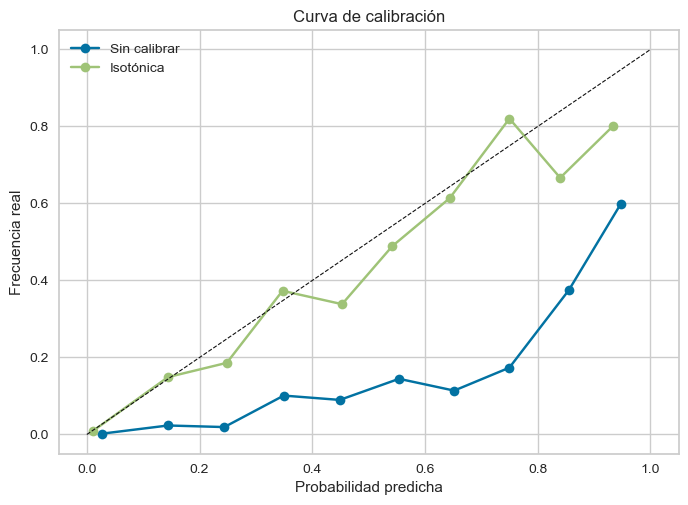

In [32]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss

# Probabilidades sin calibrar
proba_raw = pipeline_xgb_72.predict_proba(X_test)[:, 1]
brier_raw = brier_score_loss(y_test, proba_raw)
print(f"Brier score   (sin calibrar): {brier_raw:.5f}")

# Calibración isotónica (cv=5 folds)
iso_calibr = CalibratedClassifierCV(
    estimator=pipeline_xgb_72,
    method='isotonic',
    cv=5,
    n_jobs=-1
)
iso_calibr.fit(X_train, y_train)

# Probabilidades calibradas y Brier 
proba_cal = iso_calibr.predict_proba(X_test)[:, 1]
brier_cal = brier_score_loss(y_test, proba_cal)
print(f"Brier score (con calibrar):   {brier_cal:.5f}")

import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

for p, lbl in [(proba_raw, 'Sin calibrar'), (proba_cal, 'Isotónica')]:
    frac_pos, mean_pred = calibration_curve(y_test, p, n_bins=10)
    plt.plot(mean_pred, frac_pos, marker='o', label=lbl)

plt.plot([0, 1], [0, 1], '--k', linewidth=.8)
plt.xlabel('Probabilidad predicha'); plt.ylabel('Frecuencia real')
plt.legend(); plt.title('Curva de calibración'); plt.show()


La calibración isotónica convierte las puntuaciones del XGBoost en probabilidades bien escaladas y ordenadas: un 70 % predicho se traduce en ≈ 70 % de seleccionados reales. Esto facilita decisiones de negocio modulables por umbral, permite comparar el modelo con otros en un marco bayesiano y hace posibles agregaciones (promedios, riesgos) sin sesgos sistemáticos. Por lo tanto, el modelo calibrado conserva su poder predictivo y gana interpretabilidad probabilística, cumpliendo el objetivo de modularidad.